In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

print("at directory:", os.getcwd())
print("changing to root directory")
os.chdir("..")
print("at directory:", os.getcwd())

at directory: /Users/wilka/git/research/human-dyna-web/figures
changing to root directory
at directory: /Users/wilka/git/research/human-dyna-web


In [5]:
sys.path.append("simulations")

In [4]:
import polars as pl
import jax

from analysis import housemaze_model_data
from analysis import housemaze_user_data

from analysis import housemaze_analysis
from nicewebrl import dataframe


No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl


# Simulation data

In [5]:
data_dir = "/Users/wilka/git/research/results/human_dyna/"

################
# Load model data
################
# %debug
model_df = housemaze_model_data.get_model_data(
  qlearning_path=f"{data_dir}/model_data/ql/save_data/ql-big-2/tota=40000000,exp=exp2/seed=*",
  sf_path=f"{data_dir}/model_data/usfa/save_data/usfa-big-10-search/sf_h=1024,num_=2,tota=40000000,exp=exp2/seed=*",
  dyna_path=f"{data_dir}/model_data/dynaq_shared/save_data/dynaq-big-4/alg=dynaq_shared,agen=256,tota=100000000,exp=exp2/seed=*",
  preplay_path=f"{data_dir}/model_data/dynaq_shared/save_data/dynaq-big-4/alg=dynaq_shared,agen=256,tota=100000000,exp=exp2/seed=*",
  search_path=f"{data_dir}/search_algos",
  overwrite_episodes=False,
  overwrite_df=False,
)

/Users/wilka/miniforge3/envs/preplay/lib/python3.10/site-packages/jax/_src/numpy/array_methods.py:66: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return lax_numpy.astype(arr, dtype)


In [6]:
# model_df = model_df.rename({'went_to_junction': 'reuse'})

# Human data

In [7]:
from glob import glob

# ON COMPUTER
RESULTS_DIR = "/Users/wilka/git/research/"
USER_RESULTS_DIR = os.path.join(RESULTS_DIR, "results/human_dyna/user_data/exps")

human_data_pattern = "final*v2*"



files = f"{USER_RESULTS_DIR}/*{human_data_pattern}*.json"
# files = 'jaxemaze_data/*.json'
valid_files = list(set(glob(files)))
len(valid_files)

400

In [13]:
# %debug
user_df = housemaze_user_data.get_human_data(
    valid_files,
    overwrite_episode_data=False,
    overwrite_episode_info=True,
    require_finished=False,
    load_df_only=False,
    debug=False
)

No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl


Failed to unpack record in /Users/wilka/git/research/results/human_dyna/user_data/exps/user=4238060579_name=jaxmaze_final-v2-r1-t0-start_debug=0.json: unpack(b) received extra data.
ERROR:absl:Error processing file /Users/wilka/git/research/results/human_dyna/user_data/exps/user=4238060579_name=jaxmaze_final-v2-r1-t0-start_debug=0.json: 'user_info'
/Users/wilka/git/research/human-dyna-web/analysis/housemaze_user_data.py:716: RuntimeWarning: invalid value encountered in log
  return np.log(1000 * e.reaction_times + 1e-5)


Combining results:   0%|          | 0/400 [00:00<?, ?it/s]

In [14]:
len(user_df)

28293

In [15]:
user_df.filter(manipulation=4).head()

index,maze,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,start_pos,user_id,age,sex,worker_id,hit_id,assignment_id,git_version,user,debug,exp_name,tell_reuse,reversal,optimal_length,success,path_length,termination,log_first_rt,first_rt,log_avg_rt,avg_rt,log_total_rt,total_rt,log_avg_post_rt,avg_post_rt,log_max_rt,max_rt,log_max_post_rt,log_max_init_post_rt,log_max_end_rt,log_max_final_rt,optimal_length_deviance,reuse
u32,str,i64,str,str,i64,i64,i64,bool,i64,i64,str,i64,i64,str,str,str,str,str,str,str,str,i64,str,i64,f32,i64,f32,f32,f64,f32,f64,f32,f64,f32,f64,f32,f64,f32,f32,f32,f32,i64,i32
0,"""big_m4_maze_short_(F,T)""",0,"""big_m4_maze_short__(F,T)_eval1""","""See if faster off train path t…",4,0,1,false,31,0,"""[1 8]""",1900242051,22,"""Female""","""A7J34VDANY4GD""","""3PR3LXCWSFLZLRD5AL7G2YHRBCMX9T""","""32N49TQG3H4N85G9TEP0ZRRJETZAV9""","""git_version_unknown""","""1900242051""","""0""","""jaxmaze""",1,"""F,T""",23,1.0,24,1.0,7.720462,2.254,5.609728,0.360917,134.633469,8.662,5.517956,0.278609,7.720462,2.254,6.579251,6.579251,5.793014,6.214608,1,null
1,"""big_m4_maze_short_(F,T)""",0,"""big_m4_maze_short__(F,T)_eval1""","""See if faster off train path t…",4,1,2,false,31,0,"""[ 0 10]""",1900242051,22,"""Female""","""A7J34VDANY4GD""","""3PR3LXCWSFLZLRD5AL7G2YHRBCMX9T""","""32N49TQG3H4N85G9TEP0ZRRJETZAV9""","""git_version_unknown""","""1900242051""","""0""","""jaxmaze""",1,"""F,T""",18,1.0,18,1.0,7.482682,1.777,5.400545,0.294778,97.209801,5.306,5.278065,0.207588,7.482682,1.777,5.991465,5.991465,5.252274,5.252274,0,null
2,"""big_m4_maze_short_(F,T)""",0,"""big_m4_maze_short__(F,T)_eval1""","""See if faster off train path t…",4,2,3,false,31,0,"""[ 3 16]""",1900242051,22,"""Female""","""A7J34VDANY4GD""","""3PR3LXCWSFLZLRD5AL7G2YHRBCMX9T""","""32N49TQG3H4N85G9TEP0ZRRJETZAV9""","""git_version_unknown""","""1900242051""","""0""","""jaxmaze""",1,"""F,T""",17,1.0,17,1.0,7.297768,1.477,5.351681,0.270059,90.978584,4.591,5.230051,0.194625,7.297768,1.477,5.929589,5.929589,5.929589,5.17615,0,null
3,"""big_m4_maze_short_(F,T)""",0,"""big_m4_maze_short__(F,T)_eval1""","""See if faster off train path t…",4,3,4,false,31,0,"""[ 5 10]""",1900242051,22,"""Female""","""A7J34VDANY4GD""","""3PR3LXCWSFLZLRD5AL7G2YHRBCMX9T""","""32N49TQG3H4N85G9TEP0ZRRJETZAV9""","""git_version_unknown""","""1900242051""","""0""","""jaxmaze""",1,"""F,T""",17,1.0,17,1.0,7.41216,1.656,5.412614,0.293471,92.014442,4.989,5.287642,0.208312,7.41216,1.656,5.929589,5.929589,5.768321,5.768321,0,null
4,"""big_m4_maze_short_(F,T)""",0,"""big_m4_maze_short__(F,T)_eval1""","""See if faster off train path t…",4,4,5,false,31,0,"""[ 0 10]""",1900242051,22,"""Female""","""A7J34VDANY4GD""","""3PR3LXCWSFLZLRD5AL7G2YHRBCMX9T""","""32N49TQG3H4N85G9TEP0ZRRJETZAV9""","""git_version_unknown""","""1900242051""","""0""","""jaxmaze""",1,"""F,T""",18,1.0,18,1.0,7.457032,1.732,5.345537,0.279278,96.219658,5.026999,5.221331,0.193824,7.457032,1.732,5.886104,5.886104,5.693732,5.693732,0,null


# Analysis

In [16]:
# !pip install statsmodels

In [17]:
save_dir = f"{data_dir}/housemaze_analysis_results_final/"

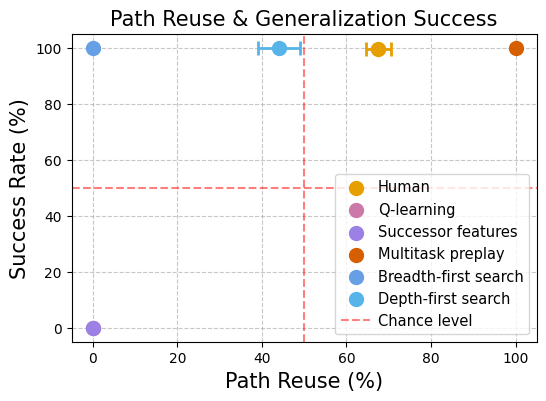

Filtered 0 rows with null success or reuse
Loading cached results from temp/statsfile.log_max_rt_reuse_1.pkl
n no_reuse: 63
n reuse: 87


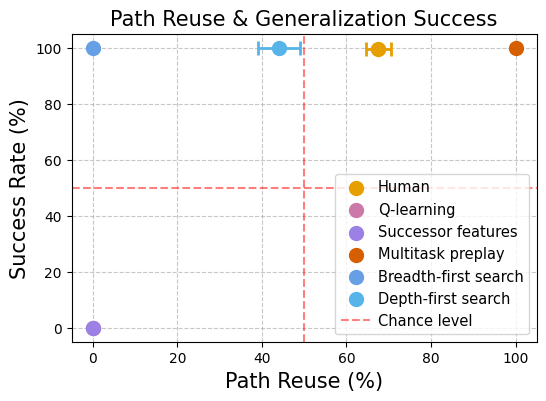

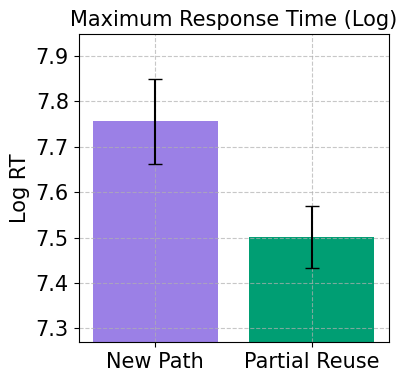

Filtered 0 rows with null success or reuse
Loading cached results from temp/statsfile.log_first_rt_reuse_1.pkl
n no_reuse: 63
n reuse: 87


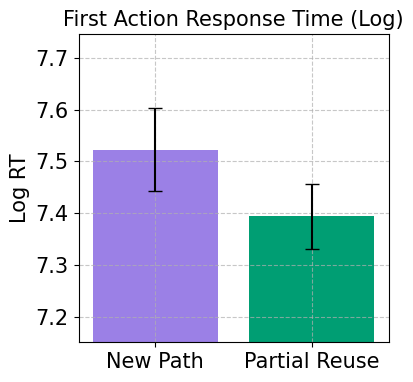

Filtered 0 rows with null success or reuse
Loading cached results from temp/statsfile.first_rt_reuse_1.pkl
n no_reuse: 63
n reuse: 87


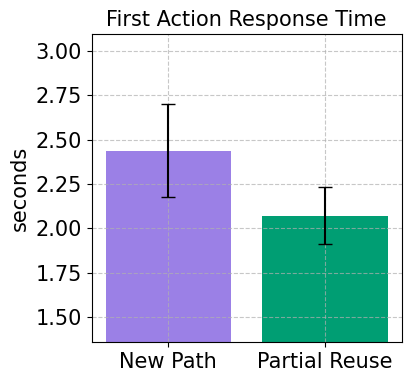

Filtered 0 rows with null success or reuse
Loading cached results from temp/statsfile.max_rt_reuse_1.pkl
n no_reuse: 63
n reuse: 87


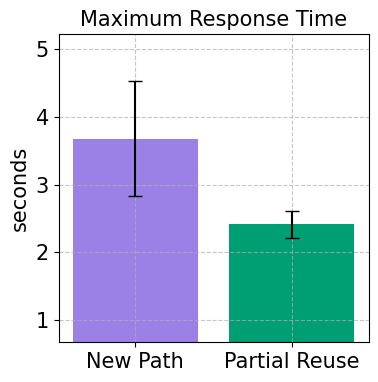

Filtered 0 rows with null success or reuse
Loading cached results from temp/statsfile.total_rt_reuse_1.pkl
n no_reuse: 63
n reuse: 87


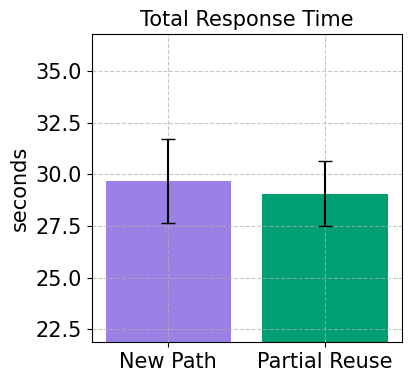

Experiment 1 Statistical Analysis


Analysis Results:
N = 91 participants (mean 4.0 trials per participant)
Mean reuse rate: 0.676 (SE: 0.030)

Normality Test (Shapiro-Wilk):
p = 0.000 (Non-normal distribution)

Wilcoxon signed-rank test:
statistic = 2052.500
p = 0.000

Effect Size (r):
0.513

Required Sample Sizes:
Power 80%: N ≥ 7 participants
Power 90%: N ≥ 8 participants
Power 95%: N ≥ 10 participants

Reaction Time Analysis

log_max_rt
--------------------

log_first_rt
--------------------

first_rt
--------------------

max_rt
--------------------

total_rt
--------------------



In [40]:
data_dir = "/Users/wilka/git/research/results/human_dyna/"
# %debug
housemaze_analysis.path_reuse_results(
  user_df,
  model_df,
  save_dir=save_dir,
  tell_reuse=1,
  display_figs=True,
  save_figs=True,
  n_simulations=1,
  verbosity=1,
  rereun_analysis=False,
  # rt_ylim=[[7,8][7,8], [1.5, 3], [2,5],[],
)

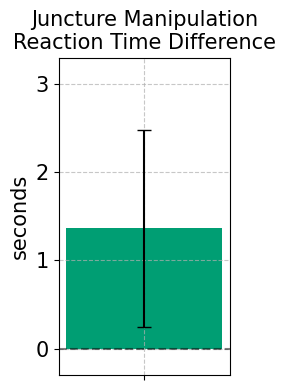

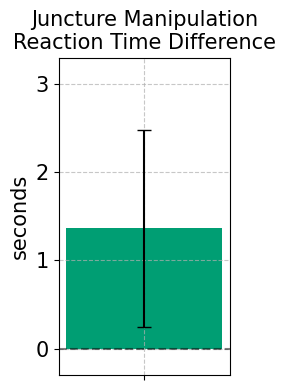

In [47]:
data_dir = "/Users/wilka/git/research/results/human_dyna/"
# save_dir = f"{data_dir}/housemaze_analysis_results_combined/"
# %debug
housemaze_analysis.juncture_results(
  user_df,
  # model_df,
  save_dir=save_dir,
  save_figs=True,
  display_figs=True,
  figsize=(2.5, 4),
  options=[('short', 0)],
  show_legend=False,
    measure='first_rt',
    ylim=[0, 3],
)

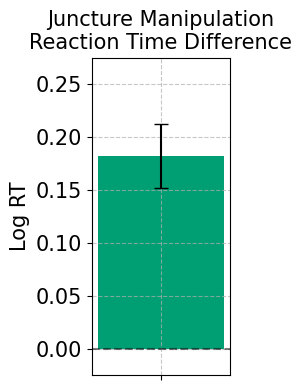

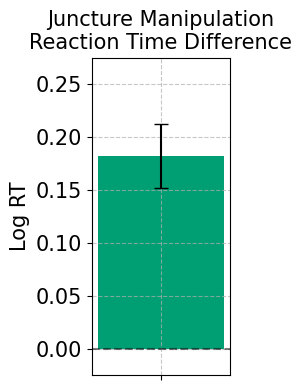

In [46]:
data_dir = "/Users/wilka/git/research/results/human_dyna/"
# save_dir = f"{data_dir}/housemaze_analysis_results_combined/"
# %debug
housemaze_analysis.juncture_results(
  user_df,
  # model_df,
  save_dir=save_dir,
  save_figs=True,
  display_figs=True,
  figsize=(2.5, 4),
  options=[('short', 0)],
  show_legend=False,
    # measure='first_rt',
  ylim=[0, .25],
)

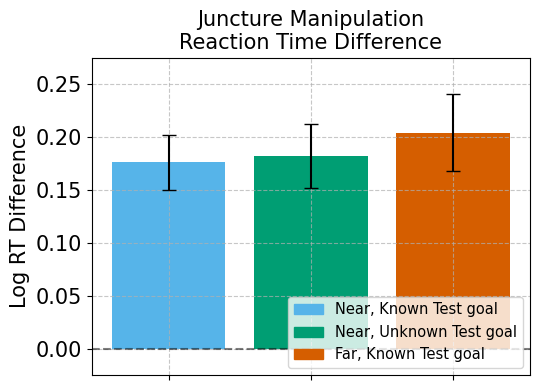

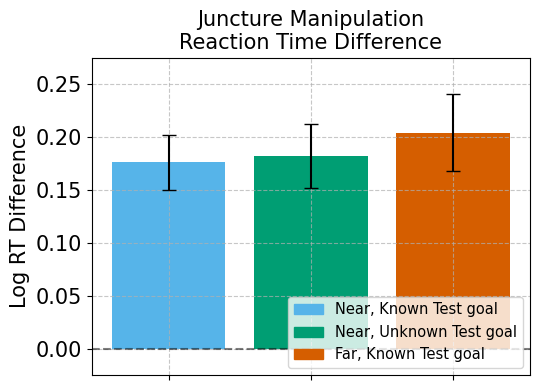

No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze

In [24]:
data_dir = "/Users/wilka/git/research/results/human_dyna/"
# save_dir = f"{data_dir}/housemaze_analysis_results_combined/"
# %debug
housemaze_analysis.juncture_results(
  user_df,
  # model_df,
  save_dir=save_dir,
  save_figs=True,
  display_figs=True,
  # figsize=(2.5, 4),
  # options=[('short', 0)],
    # show_legend=False,
    ylim=[0, .25],
)

No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
removed: user 2839222451 rate: 1.0 = 1/16. n=1
removed: user 3995656540 rate: 0.8888888955116272 = 8/16. n=9


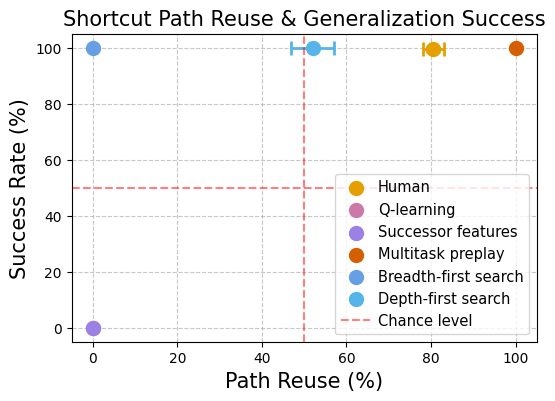

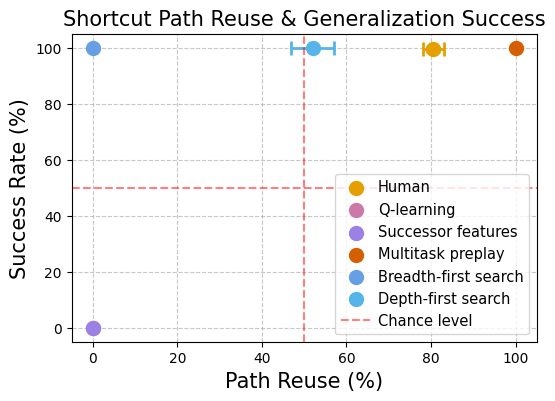

In [32]:
data_dir = '/Users/wilka/git/research/results/human_dyna/'
save_dir = f'{data_dir}/analysis_results/'
housemaze_analysis.shortcut_results(
    user_df,
    model_df,
    save_dir=save_dir,
    display_figs=True,
    save_figs=True)

No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl


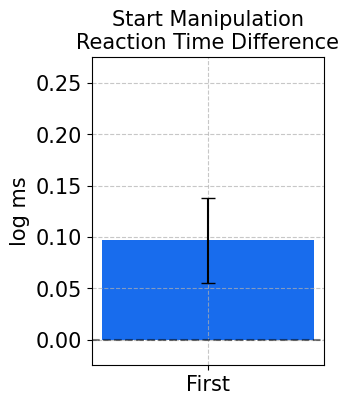

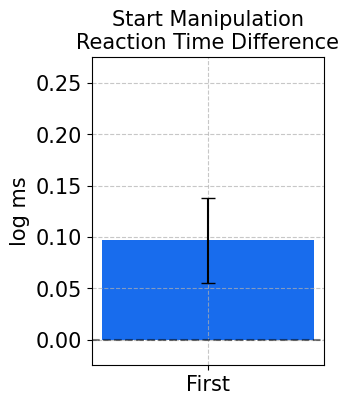

In [40]:
data_dir = '/Users/wilka/git/research/results/human_dyna/'
save_dir = f'{data_dir}/analysis_results/'
housemaze_analysis.start_results(
    user_df,
    # model_df,
    save_dir=save_dir,
    ylim=[0, .25],
    display_figs=True,
    save_figs=True)